In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from scipy.spatial.distance import cdist
import warnings
import pickle as pkl
import os
warnings.simplefilter("ignore")

In [28]:
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)

In [29]:
from mtu_plots import graph_metrics_models_and_mtu

In [30]:
model_keys = [
    #"ideal",
    #"content_5",
    #"content_10",
    #"pop",
    #"mf",
    #"sf",
    "random",
    "random_patched",
]

metric_list = [
    "interaction_history",
    "decisions",
    "utility_history",
    "trait_history",
    "rank_history",
    ]

feed_names = [
    "rand_feed",
    #"pop_feed",
    #"trend_feed",
    #"new_feed",
    #"social_feed",
    #"ideal_feed",
    #"any_feed",
    ]

In [31]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})
plotting_sigma = 0.1
mult_sd = 0.25

rs_colors = {
    'content_5' : 'tab:green',
    'content_10' : 'tab:orange',
    'pop' : 'tab:red',
    'sf' : 'tab:brown',
    'mf' : 'tab:purple',
    'ideal' : 'tab:blue',
    'random' : 'tab:pink',
    'random_patched' : 'magenta'
}

# readable legend keys
model_to_readable = {
    #"ideal": "Ideal",
    #"content_5": "Content Filtering 5 Tags",
    #"content_10": "Content Filtering 10 Tags",
    #"pop": "Popularity",
    #"mf" : "Matrix Factorization",
    #"sf": "Social Filtering", 
    "random": "Random",
    "random_patched": "Random Patched"
}

feed_names_to_readable = {
    "rand_feed": "Rand",
    #"pop_feed": "Pop",
    #"trend_feed": "Trend",
    #"new_feed": "New",
    #"social_feed": "Social",
    #"ideal_feed": "Ideal",
    #"any_feed": "Any",
}

In [32]:
os.path

<module 'posixpath' from '/home/salveal/anaconda3/lib/python3.8/posixpath.py'>

In [33]:
results_file = "/home/salveal/data/salveal/results14"
inpi = 40
all_folder_paths = {feed_folder_path : [results_file + "/" + feed_folder_path + "/r" + str(i) for i in [0,5]]
                    for feed_folder_path in feed_names}
#all_results_to_readable = {feed: {all_folder_paths[feed][i]: (("RS: "*int(i==0))+str(100-20*i))
#                                                                 +"%\n"
#                                                                 +(((feed_names_to_readable[feed] + ": ")*int(i==0))+str(20*i))
#                                                                 +"%" 
#                                for i in [0,5]} 
#                           for feed in feed_names}
#all_results_to_readable["social_feed"][all_folder_paths["social_feed"][5]] = "1%\n99%"

In [34]:
all_final_results = dict()
all_item_attrs = dict()
for feed, folder_paths in all_folder_paths.items():
    final_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for folder_path in folder_paths:
        filepath = os.path.join(folder_path, "sim_results.pkl")
        results = pkl.load(open(filepath, "rb"))
        for metric_name, v in results.items():
            for model_name, metric_vals in v.items():
                final_results[metric_name][model_name][folder_path] += np.array(metric_vals).tolist()
    all_final_results[feed] = final_results
    all_item_attrs[feed] = np.array(final_results['item_attrs']['all'][folder_paths[0]])

In [35]:
all_interactions = dict()
all_user_iter_attrs_ideals = dict()
for feed, folder_paths in all_folder_paths.items():
    interactions = dict()
    for mo in model_keys:
        print(mo)
        interactions[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            interactions[mo][fo] = np.array(all_final_results[feed]['interaction_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['interaction_history'][mo][fo])
            interactions[mo][fo] = np.transpose(interactions[mo][fo].reshape(interactions[mo][fo].shape[:-1]), axes=[0,2,1])
    all_interactions[feed] = interactions
    # I suspect this last line is the same for all feeds but i'll need to test that
    #all_user_iter_attrs_ideals[feed] = np.array([all_item_attrs[feed][i].T[interactions['ideal'][folder_paths[0]][i]] for i in range(interactions['ideal'][folder_paths[0]].shape[0])])

random
random_patched


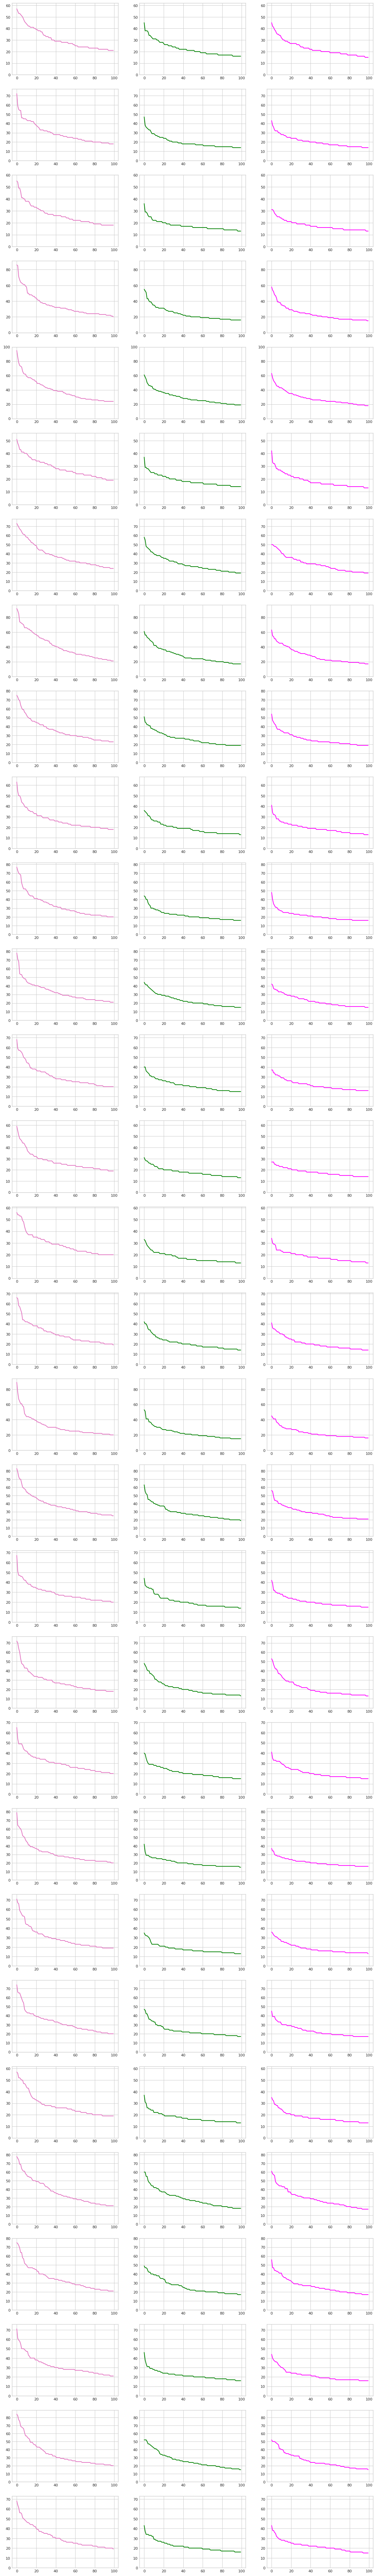

In [36]:
RandomRS = all_interactions["rand_feed"]["random"][all_folder_paths["rand_feed"][0]]
RandomFeed = all_interactions["rand_feed"]["random"][all_folder_paths["rand_feed"][1]]
RandomRSPatched = all_interactions["rand_feed"]["random_patched"][all_folder_paths["rand_feed"][0]]

total_sims = RandomRS.shape[0]
total_items = inpi*RandomRS.shape[2]
RandomRS_item_interactions = np.apply_along_axis(np.bincount,
                                axis=1,
                                arr=RandomRS.reshape(total_sims, -1),
                                minlength = total_items)
RandomFeed_item_interactions = np.apply_along_axis(np.bincount,
                                axis=1,
                                arr=RandomFeed.reshape(total_sims, -1),
                                minlength = total_items)
RandomRSPatched_item_interactions = np.apply_along_axis(np.bincount,
                                    axis=1,
                                    arr=RandomRSPatched.reshape(total_sims, -1),
                                    minlength = total_items)

ordered_RandomRS = np.sort(RandomRS_item_interactions, axis=1)[:,::-1]
ordered_RandomFeed = np.sort(RandomFeed_item_interactions, axis=1)[:,::-1]
ordered_RandomRSPatched = np.sort(RandomRSPatched_item_interactions, axis=1)[:,::-1]

plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(total_sims, 3, figsize=(14, 100))  # total_sims rows, 2 columns, 
#fig.subplots_adjust(hspace=0.2, wspace=0.2)
lower_ylim = 0.0
max_xlim = 100
for i in range(total_sims):
    values_rs = ordered_RandomRS[i,:max_xlim]
    values_feed = ordered_RandomFeed[i,:max_xlim]
    values_patched = ordered_RandomRSPatched[i,:max_xlim]
    upper_ylim = np.concatenate((values_rs, values_feed, values_patched)).max() + 5

    ax = axes[i, 0]
    ax.plot(np.arange(max_xlim), values_rs, color="tab:pink")
    ax.set_ylim((lower_ylim, upper_ylim))

    ax = axes[i, 1]
    ax.plot(np.arange(max_xlim), values_feed, color="green")
    ax.set_ylim((lower_ylim, upper_ylim))

    ax = axes[i, 2]
    ax.plot(np.arange(max_xlim), values_patched, color="magenta")
    ax.set_ylim((lower_ylim, upper_ylim))
plt.show()

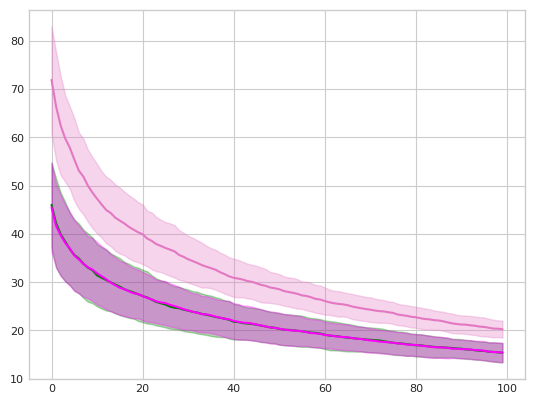

In [37]:
lower_ylim = 0.0
mult_sd = 1

values_rs = ordered_RandomRS[:,:max_xlim].mean(axis=0)
values_feed = ordered_RandomFeed[:,:max_xlim].mean(axis=0)
values_patched = ordered_RandomRSPatched[:,:max_xlim].mean(axis=0)
#upper_ylim = np.concatenate((values_rs, values_feed)).max() + 5

plt.plot(np.arange(max_xlim), values_rs, color="tab:pink")
plt.plot(np.arange(max_xlim), values_feed, color="green")
plt.plot(np.arange(max_xlim), values_patched, color="magenta")

std = ordered_RandomRS[:,:max_xlim].std(axis=0)
low = values_rs - mult_sd * std
high_rs = values_rs + mult_sd * std
plt.fill_between(np.arange(max_xlim), low, high_rs, color="tab:pink", alpha=0.3)

std = ordered_RandomFeed[:,:max_xlim].std(axis=0)
low = values_feed - mult_sd * std
high_feed = values_feed + mult_sd * std
plt.fill_between(np.arange(max_xlim), low, high_feed, color="green", alpha=0.3)

std = ordered_RandomRSPatched[:,:max_xlim].std(axis=0)
low = values_patched - mult_sd * std
high_patched = values_patched + mult_sd * std
plt.fill_between(np.arange(max_xlim), low, high_patched, color="magenta", alpha=0.3)

upper_ylim = np.concatenate((high_rs, high_feed, high_patched)).max() + 5
ax.set_ylim((lower_ylim, upper_ylim))
plt.show()